Example of how to parse the files and load data in dataframes.

In [24]:
#%pip install matplotlib

import os
import matplotlib.pyplot as plt
import matplotlib
import math
matplotlib.use('TkAgg')
%matplotlib notebook
%matplotlib inline


In [25]:
data_path = os.getcwd() + os.sep + 'data'
print(data_path)

C:\Users\Filip\Documents\Examensarbete\data


In [26]:
# Loading data functions
def loader(data_path, blacklist):
    data = []
    all_data_csv = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
    for name in os.listdir(data_path):
        if name != '.DS_Store' and 'csv' not in name and 'txt' not in name:
            print('---------------------------------------------')
            print("Loading walking data for subject: ",name)
            new_path = data_path + os.sep + name
            for name_in in os.listdir(new_path):
                if name_in != '.DS_Store' and name_in not in blacklist:
                    print("Loading test: ", name_in)
                    motion_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'motion.csv')
                    position_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'positions.csv')
                    orientation_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'orientation.csv')
                    steps_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'steps.csv')
                    event_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'events.csv')

                    anon_test = walking_test(
                        name_in, event_csv,
                        motion_csv,
                        orientation_csv,
                        position_csv,
                        steps_csv
                    )
                    data.append(anon_test)

    return data, all_data_csv

class walking_test:
    def __init__(self, filename, events, motion, orientation, positions, steps): #
        self.filename = filename
        self.events = events
        self.motion = motion
        self.orientation = orientation
        self.positions = positions
        self.steps = steps

In [27]:
#%pip install pandas

import pandas as pd

# Uploading metadata and determining blacklist
metadata = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
print("Metadata columns: ", metadata.columns)

noIMU = metadata[metadata['hasMotion'] == False]['testName'].tolist()
noGPS = metadata[metadata['hasGNSS'] == False]['testName'].tolist()
blacklist = noIMU + noGPS
print("Blacklist: ", blacklist)

Metadata columns:  Index(['subject', 'testID', 'testName', 'isPatient', 'distanceReference',
       'hasMotion', 'hasGNSS', 'device', 'distanceByApp', 'totSteps',
       'path curvature', 'total_gaps_time_inertial', 'total_gaps_time_gnss',
       'gt_type', 'country', 'gnss_anonimized', 'duration [s]', 'fs_acc',
       'fs_gnss', 'fs_steps', 'average_walking_speed', 'smartphone_position',
       'smartphone app'],
      dtype='object')
Blacklist:  ['0_0', '0_1', '0_2', '0_3', '0_4', '0_5', '0_6', '0_7', '0_8', '0_9', '0_10', '0_11', '0_12', '0_13', '0_14', '1_0', '1_1', '1_2', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '2_0', '2_1', '2_2', '2_3', '2_4', '2_5', '2_6', '2_7', '2_8', '2_9', '3_0', '3_5', '3_6', '3_7', '3_8', '3_9', '9_0', '9_1', '9_2', '9_3', '9_4', '9_5', '9_6', '9_7', '9_8', '9_9', '9_10', '15_0', '15_1', '15_2', '15_3', '15_4']


In [28]:
metadata.head()

,subject,testID,testName,isPatient,distanceReference,hasMotion,hasGNSS,device,distanceByApp,totSteps,...,gt_type,country,gnss_anonimized,duration [s],fs_acc,fs_gnss,fs_steps,average_walking_speed,smartphone_position,smartphone app
0,0,0,0_0,True,623,False,True,"Apple iPhone11,8",598.373421,755.0,...,final,UK,True,368,NaN,0.304348,0.380435,1.692935,hand held,Timed Walk
1,0,1,0_1,True,598,False,True,"Apple iPhone11,8",587.334804,699.0,...,final,UK,True,380,NaN,0.292105,0.357895,1.573684,hand held,Timed Walk
2,0,2,0_2,True,584,False,True,"Apple iPhone11,8",577.005522,726.0,...,final,UK,True,359,NaN,0.281337,0.381616,1.626741,hand held,Timed Walk
3,0,3,0_3,True,577,False,True,"Apple iPhone11,8",539.365038,710.0,...,final,UK,True,365,NaN,0.284932,0.372603,1.580822,hand held,Timed Walk
4,0,4,0_4,True,590,False,True,"Apple iPhone11,8",566.744323,715.0,...,final,UK,True,360,NaN,0.277778,0.375000,1.638889,hand held,Timed Walk


In [29]:
# Loading data
selection, info_all_tests = loader(data_path, blacklist=blacklist)
print("Successfully loaded data")

---------------------------------------------
Loading walking data for subject:  subject_0
---------------------------------------------
Loading walking data for subject:  subject_1
---------------------------------------------
Loading walking data for subject:  subject_10
Loading test:  10_0
Loading test:  10_1
Loading test:  10_10
Loading test:  10_11
Loading test:  10_12
Loading test:  10_13
Loading test:  10_14
Loading test:  10_15
Loading test:  10_16
Loading test:  10_17
Loading test:  10_2
Loading test:  10_3
Loading test:  10_4
Loading test:  10_5
Loading test:  10_6
Loading test:  10_7
Loading test:  10_8
Loading test:  10_9
---------------------------------------------
Loading walking data for subject:  subject_11
Loading test:  11_0
Loading test:  11_1
Loading test:  11_10
Loading test:  11_11
Loading test:  11_12
Loading test:  11_13
Loading test:  11_14
Loading test:  11_15
Loading test:  11_2
Loading test:  11_3
Loading test:  11_4
Loading test:  11_5
Loading test:  11_6


## Data

In [30]:
rows, columns = metadata.shape
print(f"The dataset has {rows} rows and {columns} columns.")

The dataset has 203 rows and 23 columns.


In [31]:
# Example of what a walking test contains:
print("Selection[0] contains: ")
print("Filename: ", selection[0].filename)
#Events
print("Events: ", selection[0].events.head())
#Motion
print("Motion: ", selection[0].motion.head())
#Orientation
print("Orientation: ", selection[0].orientation.head())
#Positions
print("Positions: ", selection[0].positions.head())
#Steps
print("Steps: ", selection[0].steps.head())

Selection[0] contains: 
Filename:  10_0
Events:     Unnamed: 0  signalStart  testStart        testEnd
0           0            0     1481.0  361167.000055
Motion:     Unnamed: 0     ms  accelX  accelY  accelZ  accelWithGX  accelWithGY  \
0           0  178.0    -0.1     0.0     0.2         -0.2          3.2   
1           1  192.0    -0.1     0.0     0.3         -0.2          3.2   
2           2  200.0    -0.1    -0.1     0.3         -0.3          3.1   
3           3  218.0    -0.1    -0.2     0.4         -0.2          2.9   
4           4  234.0    -0.1    -0.2     0.4         -0.3          2.9   

   accelWithGZ  rotRateAlpha  rotRateBeta  rotRateGamma  interval  
0          9.4          -2.6          0.8           3.3        16  
1          9.4          -2.6          0.8           3.3        16  
2          9.6          -2.8         -1.4           3.4        16  
3          9.7          -1.6         -2.1           2.4        16  
4          9.8           0.5         -3.4          

## Crowdistans

In [32]:
#Saras code
def crowDist(point1, point2):
    lat1 = point1.latitude
    lat2 = point2.latitude
    lon1 = point1.longitude
    lon2 = point2.longitude
    R = 6371  # km
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    a = math.sin(dLat / 2) * math.sin(dLat / 2) + \
        math.sin(dLon / 2) * math.sin(dLon / 2) * math.cos(lat1) * math.cos(lat2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = R * c
    return d * 1000

## Calculating distans

In [33]:
import math

for test in selection:
    positions_data = test.positions.copy()  # Important to copy the data to avoid modifying the original

    # Convert time to seconds from start
    positions_data['time_s'] = (positions_data['ms'] - positions_data['ms'].min()) / 1000

    # Calculate distance between points (protects against index errors)
    distances = [0] + [
        crowDist(positions_data.iloc[i-1], positions_data.iloc[i])
        for i in range(1, len(positions_data))
    ]
    positions_data['distance_m'] = distances

    # Total distance
    total_distance = positions_data['distance_m'].sum()
    print(f"Total distance traveled for {test.filename}: {total_distance:.2f} meters")

    # Calculate time difference between measurement points
    positions_data['delta_time_s'] = positions_data['time_s'].diff()

    # Protect against division by small values or zero
    min_time_threshold = 0.1  # Minimum allowed time difference in seconds
    positions_data['delta_time_s'] = positions_data['delta_time_s'].clip(lower=min_time_threshold)

    # Calculate speed in m/s
    positions_data['speed_mps'] = positions_data['distance_m'] / positions_data['delta_time_s']



Total distance traveled for 10_0: 443.74 meters
Total distance traveled for 10_1: 438.21 meters
Total distance traveled for 10_10: 183.98 meters
Total distance traveled for 10_11: 217.64 meters
Total distance traveled for 10_12: 279.55 meters
Total distance traveled for 10_13: 1609.47 meters
Total distance traveled for 10_14: 365.60 meters
Total distance traveled for 10_15: 450.26 meters
Total distance traveled for 10_16: 176.26 meters
Total distance traveled for 10_17: 322.75 meters
Total distance traveled for 10_2: 547.44 meters
Total distance traveled for 10_3: 882.35 meters
Total distance traveled for 10_4: 468.01 meters
Total distance traveled for 10_5: 514.02 meters
Total distance traveled for 10_6: 633.07 meters
Total distance traveled for 10_7: 568.23 meters
Total distance traveled for 10_8: 260.15 meters
Total distance traveled for 10_9: 368.16 meters
Total distance traveled for 11_0: 570.14 meters
Total distance traveled for 11_1: 433.85 meters
Total distance traveled for 11_

## Traning a modell

Epoch 1/10


C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1618
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0111
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0038
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0024
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0017
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0013
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9.8098e-04
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.1305e-04
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.3598e-04
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 6.9529e-04

Prediction over 360 seconds:
Actual final distance: 855.54 m
Predicted final distance: 294.58 m
Absolute difference in final distance: 560.96 meters
Relative error in final distance: 65.57 %


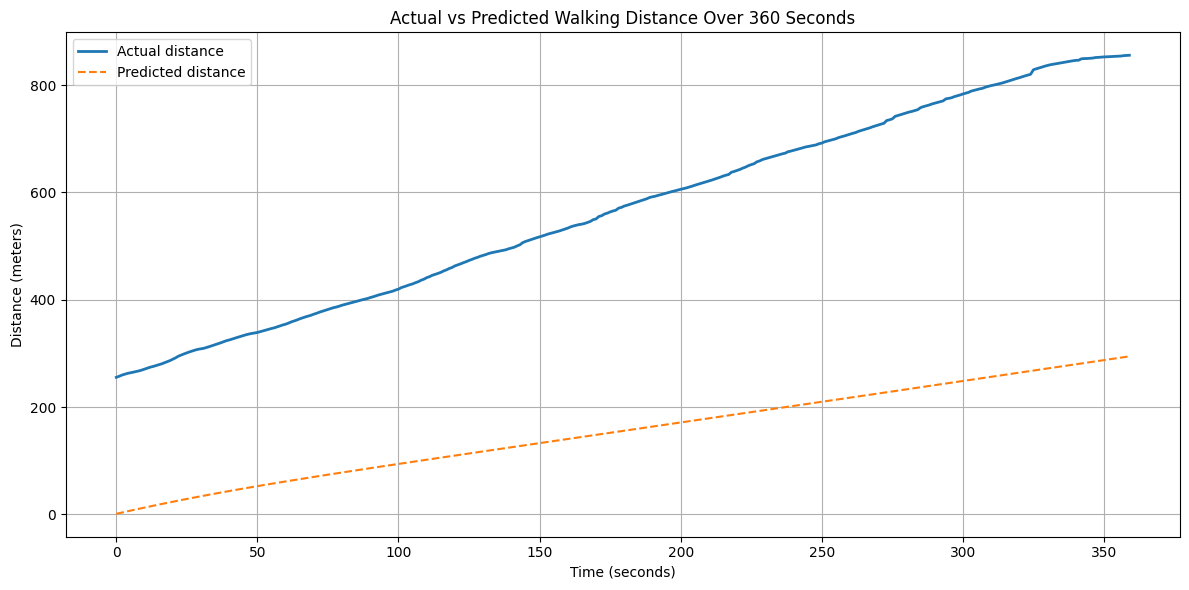

In [34]:
#%pip install tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

# Prepare data
positions_data = positions_data[['latitude', 'longitude', 'altitude', 'speed_mps']].dropna()

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(positions_data.values)

# Create dataset
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), :])
        y.append(data[i + time_step, :])
    return np.array(X), np.array(y)

time_step = 100
X, y = create_dataset(scaled_data, time_step)
X = X.reshape(X.shape[0], X.shape[1], scaled_data.shape[1])

# Build GRU model
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(GRU(units=50))
model.add(Dense(units=scaled_data.shape[1]))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model.fit(X, y, epochs=10, batch_size=32)

# Iterative prediction for 360 seconds
prediction_seconds = 360
input_sequence = scaled_data[-time_step:].reshape(1, time_step, scaled_data.shape[1])
predictions_scaled = []

for _ in range(prediction_seconds):
    pred = model.predict(input_sequence, verbose=0)[0]
    predictions_scaled.append(pred)
    input_sequence = np.append(input_sequence[:, 1:, :], [[pred]], axis=1)

# Inverse transform to original scale
predictions = scaler.inverse_transform(np.array(predictions_scaled))

# Extract predicted speeds
predicted_speeds = predictions[:, 3]  # index 3 = speed_mps
predicted_cumulative_distance = np.cumsum(predicted_speeds)

# Actual distance over same time span
actual_speeds = positions_data['speed_mps'].values[:prediction_seconds]
actual_cumulative_distance = np.cumsum(actual_speeds)

# Ensure equal lengths
min_len = min(len(predicted_cumulative_distance), len(actual_cumulative_distance))
predicted_cumulative_distance = predicted_cumulative_distance[:min_len]
actual_cumulative_distance = actual_cumulative_distance[:min_len]

# Error metrics for full distance curves
mae = mean_absolute_error(actual_cumulative_distance, predicted_cumulative_distance)
mse = mean_squared_error(actual_cumulative_distance, predicted_cumulative_distance)
rmse = math.sqrt(mse)

# Error in final distance only (total predicted vs actual)
final_actual_distance = actual_cumulative_distance[-1]
final_predicted_distance = predicted_cumulative_distance[-1]
end_diff = abs(final_predicted_distance - final_actual_distance)
rel_error = end_diff / final_actual_distance * 100

# Output
print(f"\nPrediction over 360 seconds:")
print(f"Actual final distance: {final_actual_distance:.2f} m")
print(f"Predicted final distance: {final_predicted_distance:.2f} m")
print(f"Absolute difference in final distance: {end_diff:.2f} meters")
print(f"Relative error in final distance: {rel_error:.2f} %")

# Plot: Actual vs Predicted cumulative distance
plt.figure(figsize=(12, 6))
plt.plot(actual_cumulative_distance, label='Actual distance', linewidth=2)
plt.plot(predicted_cumulative_distance, label='Predicted distance', linestyle='--')
plt.xlabel('Time (seconds)')
plt.ylabel('Distance (meters)')
plt.title('Actual vs Predicted Walking Distance Over 360 Seconds')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 6.6117e-04 - val_loss: 6.9317e-04
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 6.7952e-04 - val_loss: 6.7118e-04
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 6.1622e-04 - val_loss: 6.5958e-04
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 6.1116e-04 - val_loss: 8.1681e-04
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 5.4711e-04 - val_loss: 8.3836e-04
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 5.5302e-04 - val_loss: 7.5662e-04
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 4.9721e-04 - val_loss: 7.6902e-04
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 4.2698e-04 - val_loss: 8.0817e-04
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 4.0401e-04 - val_loss: 9.2555e-04
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4.5943e-04 - val_loss: 8.8808e-04
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 4.7250e-0

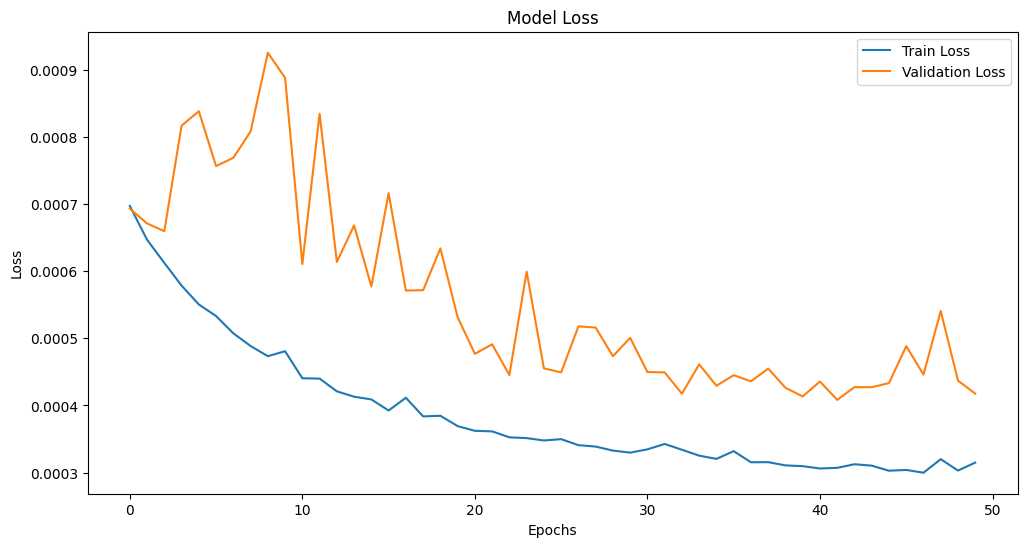

In [35]:
# Train the model and store the training history
history = model.fit(X, y, validation_split=0.2, epochs=50, batch_size=32)

# Visualize the training process
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



In [36]:
rows, columns = metadata.shape
print(f"The dataset has {rows} rows and {columns} columns.")

The dataset has 203 rows and 23 columns.


### Boxplot

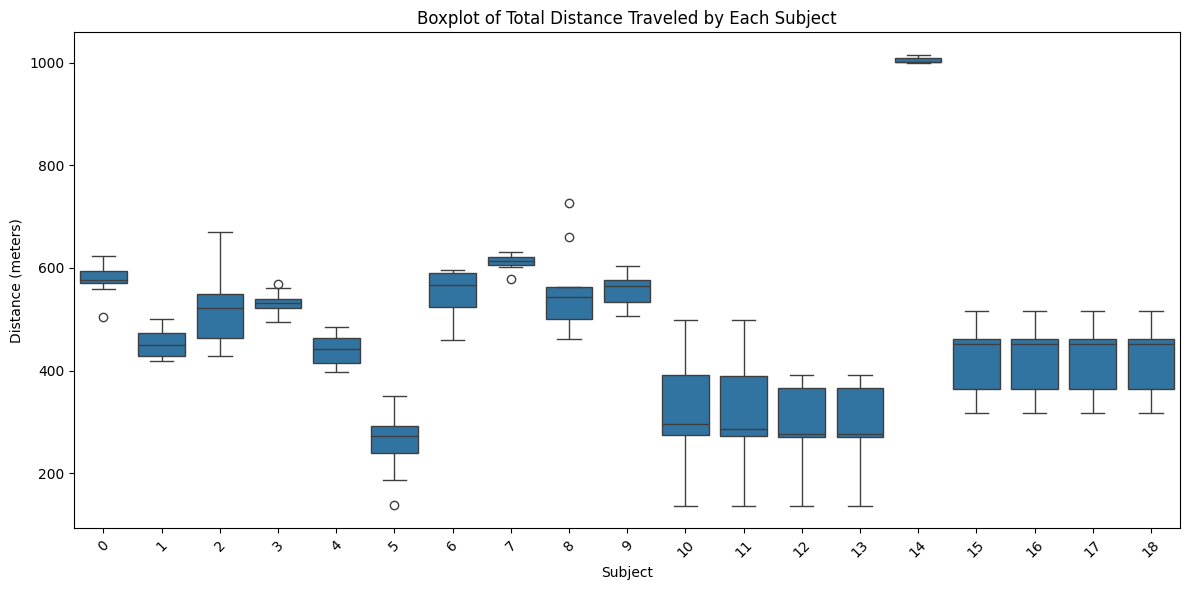

In [37]:
import seaborn as sns

# Extract the subject name
metadata['Subject'] = metadata['testName'].str.split('_').str[0]

# Prepare data for the boxplot
boxplot_data = metadata[['Subject', 'distanceReference']].rename(columns={'distanceReference': 'Distance (m)'})

# Boxplot for total distance traveled by each subject
plt.figure(figsize=(12, 6))
sns.boxplot(x='Subject', y='Distance (m)', data=boxplot_data)
plt.title('Boxplot of Total Distance Traveled by Each Subject')
plt.xlabel('Subject')
plt.ylabel('Distance (meters)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [38]:
metadata[(metadata['subject'] == 14)]

,subject,testID,testName,isPatient,distanceReference,hasMotion,hasGNSS,device,distanceByApp,totSteps,...,country,gnss_anonimized,duration [s],fs_acc,fs_gnss,fs_steps,average_walking_speed,smartphone_position,smartphone app,Subject
168,14,0,14_0,False,1000,True,True,Xiaomi Redmi Note 9 Pro,1035.164078,1366.0,...,SE,False,873,59.980527,1.002291,1.565865,1.145475,hand held,Malisa,14
169,14,1,14_1,False,1005,True,True,Xiaomi Redmi Note 9 Pro,987.643819,1254.0,...,SE,False,761,59.939553,1.005256,1.649146,1.320631,hand held,Malisa,14
170,14,2,14_2,False,1001,True,True,Xiaomi Redmi Note 9 Pro,1002.676164,1272.0,...,SE,False,774,59.979328,1.003876,1.644703,1.293282,hand held,Malisa,14
171,14,3,14_3,False,1011,True,True,Xiaomi Redmi Note 9 Pro,1011.892553,1165.0,...,SE,False,665,59.939850,1.004511,1.753383,1.520301,hand held,Malisa,14
172,14,4,14_4,False,1002,True,True,Xiaomi Redmi Note 9 Pro,1042.694672,1068.0,...,SE,False,582,59.915808,1.001718,1.838488,1.721649,hand held,Malisa,14
173,14,5,14_5,False,1011,True,True,Xiaomi Redmi Note 9 Pro,1021.284249,1097.0,...,SE,False,611,59.949264,1.001637,1.797054,1.654664,hand held,Malisa,14
174,14,6,14_6,False,1001,True,True,Xiaomi Redmi Note 9 Pro,1079.731267,1578.0,...,SE,False,1061,59.947220,1.002828,1.484449,0.943450,hand held,Malisa,14
175,14,7,14_7,False,1001,True,True,Xiaomi Redmi Note 9 Pro,1037.158915,1542.0,...,SE,False,1051,59.941960,1.002854,1.469077,0.952426,hand held,Malisa,14
176,14,8,14_8,False,1001,True,True,Xiaomi Redmi Note 9 Pro,1081.468198,1554.0,...,SE,False,1018,59.975442,1.003929,1.527505,0.983301,hand held,Malisa,14
177,14,9,14_9,False,1015,True,True,Xiaomi Redmi Note 9 Pro,983.830463,1228.0,...,SE,False,752,59.988032,1.006649,1.634309,1.349734,hand held,Malisa,14


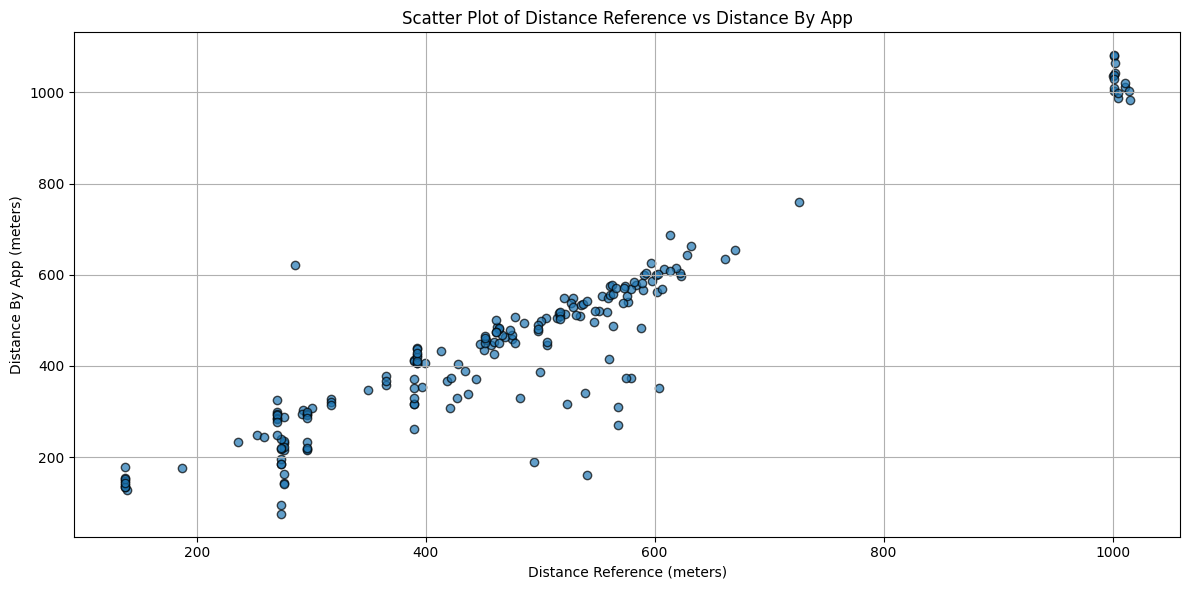

In [39]:
# Scatter plot for all test samples
plt.figure(figsize=(12, 6))
plt.scatter(metadata['distanceReference'], metadata['distanceByApp'], alpha=0.7, edgecolors='k')
plt.title('Scatter Plot of Distance Reference vs Distance By App')
plt.xlabel('Distance Reference (meters)')
plt.ylabel('Distance By App (meters)')
plt.grid(True)
plt.tight_layout()
plt.show()

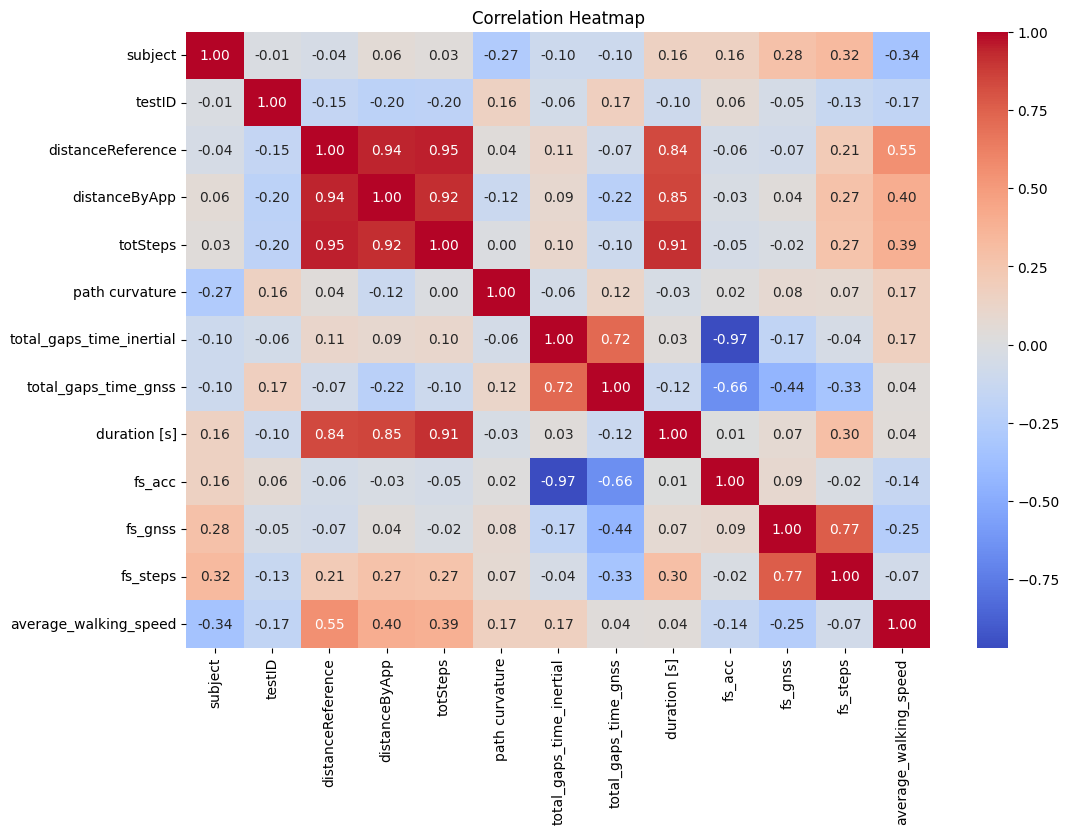

In [40]:
import seaborn as sns

import matplotlib.pyplot as plt

# Select only numeric columns for correlation
numeric_metadata = metadata.select_dtypes(include=['number'])

# Compute the correlation matrix
correlation_matrix = numeric_metadata.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

#### Loopa alla subject och gör ett dataset att visa:

In [41]:
# Antag att test.distanceReference är i meter och representerar ground truth
ground_truth_distance = metadata.distanceReference


print("Predicted distance: ", predicted_cumulative_distance[-1])
print("Ground truth distance: ", ground_truth_distance)
print("Difference (pred - truth): ", predicted_cumulative_distance[-1] - ground_truth_distance)


Predicted distance:  294.57993
Ground truth distance:  0      623
1      598
2      584
3      577
4      590
      ... 
198    317
199    365
200    452
201    461
202    517
Name: distanceReference, Length: 203, dtype: int64
Difference (pred - truth):  0     -328.420074
1     -303.420074
2     -289.420074
3     -282.420074
4     -295.420074
          ...    
198    -22.420074
199    -70.420074
200   -157.420074
201   -166.420074
202   -222.420074
Name: distanceReference, Length: 203, dtype: float64


## Kalman filter

In [42]:
# Import necessary libraries for interpolation, math, geodesic calculations, and Kalman filtering
from scipy.interpolate import interp1d
import numpy as np
import geopy
import math
from geopy.distance import geodesic
from filterpy.kalman import KalmanFilter

# Calculate the crow-fly (great-circle) distance between two points using the haversine formula
def crowDist(point1, point2):
    lat1 = point1.latitude
    lat2 = point2.latitude
    lon1 = point1.longitude
    lon2 = point2.longitude
    R = 6371  # Earth radius in km
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    a = math.sin(dLat / 2) ** 2 + math.sin(dLon / 2) ** 2 * math.cos(lat1) * math.cos(lat2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = R * c
    return d * 1000  # Convert to meters

# Calculate crow-fly distances for a sequence of positions
def calculate_crowfly_distances(position):
    coords = list(zip(position['latitude'], position['longitude']))
    distances = []
    for i in range(len(coords) - 1):
        point1 = type('Point', (object,), {'latitude': coords[i][0], 'longitude': coords[i][1]})
        point2 = type('Point', (object,), {'latitude': coords[i+1][0], 'longitude': coords[i+1][1]})
        dist = crowDist(point1, point2)
        distances.append(dist)
    return np.array(distances)

# Interpolate confidence intervals to match motion time stamps
def interpolate_confidence(confInterval, gps_time_stamps, motion_time_stamps):
    interp_func = interp1d(gps_time_stamps, confInterval, kind='linear', fill_value="extrapolate")
    return interp_func(motion_time_stamps)

# Interpolate GPS data (distance and confidence) to match motion time stamps
def interpolate_gps_data(gps_time_stamps, distance_traveled, confInterval, time_stamps):
    gps_cumsum = np.cumsum(distance_traveled)
    gps_time_stamps = gps_time_stamps[1:]
    confInterval = confInterval[1:]
    interp_fn = interp1d(gps_time_stamps, gps_cumsum, kind='linear', fill_value='extrapolate')
    interp_cumulativesum = interp_fn(time_stamps)
    interpolated_distances = np.diff(interp_cumulativesum, prepend=interp_cumulativesum[0])
    interpolated_confidence = interpolate_confidence(confInterval, gps_time_stamps, time_stamps)
    return interpolated_distances, interpolated_confidence, interp_cumulativesum

# Setup a Kalman Filter for position, velocity, and acceleration estimation
def setup_KalmanFiltering(dt, accel_magnitude, confInterval, time_stamps, distance_traveled):
    kf = KalmanFilter(dim_x=3, dim_z=3)
    # State transition matrix
    kf.F = np.array([[1, dt, 0.5 * dt**2],
                     [0, 1, dt],
                     [0, 0, 1]])
    # Initial covariance
    kf.P = np.eye(3) * 100
    # Measurement function
    kf.H = np.eye(3)
    # Measurement noise, scaled by mean confidence
    mean_confidence = np.mean(confInterval)
    R_factor = np.clip(mean_confidence, 1, 60)
    kf.R = np.array([[0.1 * R_factor, 0, 0],
                     [0, 10 * R_factor, 0],
                     [0, 0, R_factor]])
    # Control input matrix (not used here)
    kf.B = np.array([[0], [0], [1]])
    # Process noise covariance, based on acceleration std
    accel_Q = np.std(accel_magnitude)
    dt2 = dt ** 2
    dt3 = dt2 * dt / 2
    dt4 = dt2 ** 2 / 4
    kf.Q = np.array([[dt4 * accel_Q, dt3 * accel_Q, dt2 * accel_Q / 2],
                     [dt3 * accel_Q, dt2 * accel_Q, dt * accel_Q],
                     [dt2 * accel_Q / 2, dt * accel_Q, accel_Q]])
    # Initial state: position, velocity, acceleration
    initial_position = 0
    initial_velocity = (distance_traveled[1] - distance_traveled[0]) / ((time_stamps[1] - time_stamps[0]) / 1000)
    initial_acceleration = accel_magnitude[0]
    kf.x = np.array([initial_position, initial_velocity, initial_acceleration])
    return kf

# Run the Kalman Filter update loop using interpolated GPS and acceleration data
def update_Kalman_with_position(kf, accel_magnitude, distance_traveled, time_stamps, gps_time_stamps, confInterval):
    total_distance = 0.0
    previous_position = kf.x[0]
    total_loops = 0
    # Interpolate GPS and confidence to match IMU time stamps
    interpolated_distances, interpolated_confidence, observed_positions = interpolate_gps_data(
        gps_time_stamps, distance_traveled, confInterval, time_stamps
    )
    print("Original Total Distance:", np.sum(distance_traveled))
    print("Interpolated Total Distance:", np.sum(interpolated_distances))
    # Kalman filter loop
    for i in range(1, min(len(accel_magnitude), len(interpolated_distances), len(interpolated_confidence))):
        dt = (time_stamps[i] - time_stamps[i - 1]) / 1000
        accel = accel_magnitude[i]
        distance_step = interpolated_distances[i]
        # Update state transition and process noise matrices
        kf.F = np.array([[1, dt, 0.5 * dt ** 2],
                         [0, 1, dt],
                         [0, 0, 1]])
        sigma_acc = np.std(accel_magnitude) * 2
        dt2 = dt ** 2
        dt3 = dt2 * dt / 2
        dt4 = dt2 ** 2 / 4
        kf.Q = np.array([
            [dt4 * sigma_acc, dt3 * sigma_acc, dt2 * sigma_acc / 2],
            [dt3 * sigma_acc, dt2 * sigma_acc, dt * sigma_acc],
            [dt2 * sigma_acc / 2, dt * sigma_acc, sigma_acc]
        ])
        # Measurement noise based on confidence
        R_factor = np.clip(interpolated_confidence[i], 0.01, 50)
        kf.R = np.eye(3) * R_factor
        # Predict step
        kf.predict()
        # Measurement: observed position, estimated velocity, acceleration
        estimated_velocity = distance_step / dt
        z = np.array([observed_positions[i], estimated_velocity, accel])
        # Update step
        kf.update(z)
        # Accumulate total distance
        total_distance += abs(kf.x[0] - previous_position)
        previous_position = kf.x[0]
        total_loops += 1
    return kf, total_distance, total_loops

# Set time step for Kalman filter
dt = 1.0
# Calculate acceleration magnitude from IMU data
accel_magnitude = calculate_XYZ(selected_test.motion)
# Downsample time stamps for processing
downsampled_time_stamps = time_stamps[::4]
# Extract GPS time stamps and confidence intervals
gps_time_stamps = selected_test.positions['ms'].values
distance_traveled = calculate_crowfly_distances(selected_test.positions)
confInterval = selected_test.positions['confInterval']

# Initialize Kalman filter
kf = setup_KalmanFiltering(dt, accel_magnitude, confInterval, downsampled_time_stamps, distance_traveled)
# Run Kalman filter update loop
kf, total_distance, total_loops = update_Kalman_with_position(
    kf, accel_magnitude, distance_traveled, downsampled_time_stamps, gps_time_stamps, confInterval
)

# Print summary statistics
print(f"Number of time stamps: {len(downsampled_time_stamps)}")
print("Total loops:", total_loops)
print("Total Distance Traveled (after Kalman filter):", total_distance)
print("Total Raw GPS Distance:", np.sum(distance_traveled))


NameError: name 'calculate_XYZ' is not defined

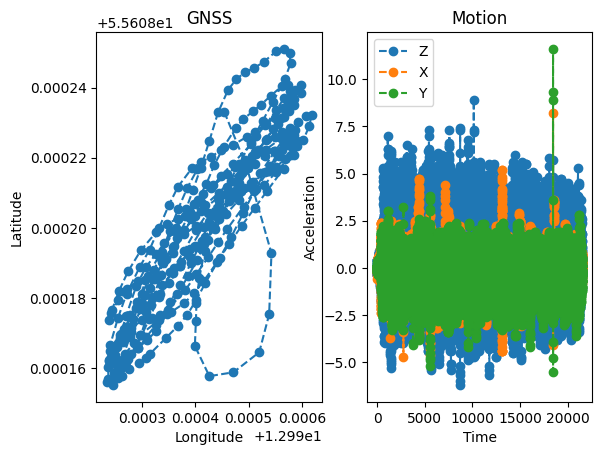

In [ ]:
# Example of how to plot position data
fig = plt.figure()
ax = fig.add_subplot(121)
ax.plot(selection[0].positions['longitude'], selection[0].positions['latitude'],'o--')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('GNSS')

ax = fig.add_subplot(122)
ax.plot(selection[0].motion['accelZ'],'o--', label='Z')
ax.plot(selection[0].motion['accelX'],'o--', label='X')
ax.plot(selection[0].motion['accelY'],'o--', label='Y')
ax.set_xlabel('Time')
ax.set_ylabel('Acceleration')
ax.legend()
ax.set_title('Motion')
plt.show()
